In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\HP\Desktop\ML\PromptWiseAI\datasets\promptwise_dataset.csv")

In [4]:
df.head()

,Prompt_ID,AI_Role,Task,Context,Constraint,Output_Format,Goal,Recommended_AI,Generated_Prompt,Timestamp
0,PW00001,Research Scientist,Research Methodology,General Professional Scenario,Return the output in Markdown,Executive Summary,Learn a Concept,Claude,You are an Research Scientist.\n\nTask:\nResea...,2026-07-04 21:36:39
1,PW00002,Senior Software Engineer,Fix Bugs,General Professional Scenario,Explain step-by-step,Executive Summary,Prepare for Interview,ChatGPT,You are an Senior Software Engineer.\n\nTask:\...,2026-07-04 21:36:39
2,PW00003,Senior Machine Learning Engineer,Tune Hyperparameters,General Professional Scenario,Provide code comments,JSON,Decision Making,ChatGPT,You are an Senior Machine Learning Engineer.\n...,2026-07-04 21:36:39
3,PW00004,Cybersecurity Specialist,Risk Mitigation,General Professional Scenario,Use Scikit-learn,Table,Learn a Concept,ChatGPT,You are an Cybersecurity Specialist.\n\nTask:\...,2026-07-04 21:36:39
4,PW00005,Business Analyst,Risk Analysis,General Professional Scenario,Provide real-world examples,Python Code,Solve a Business Problem,ChatGPT,You are an Business Analyst.\n\nTask:\nRisk An...,2026-07-04 21:36:39


In [5]:
df.shape

(2500, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Prompt_ID         2500 non-null   str  
 1   AI_Role           2500 non-null   str  
 2   Task              2500 non-null   str  
 3   Context           2500 non-null   str  
 4   Constraint        2500 non-null   str  
 5   Output_Format     2500 non-null   str  
 6   Goal              2500 non-null   str  
 7   Recommended_AI    2500 non-null   str  
 8   Generated_Prompt  2500 non-null   str  
 9   Timestamp         2500 non-null   str  
dtypes: str(10)
memory usage: 1.0 MB


In [7]:
df.isnull().sum()

Prompt_ID           0
AI_Role             0
Task                0
Context             0
Constraint          0
Output_Format       0
Goal                0
Recommended_AI      0
Generated_Prompt    0
Timestamp           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe(include="all")

,Prompt_ID,AI_Role,Task,Context,Constraint,Output_Format,Goal,Recommended_AI,Generated_Prompt,Timestamp
count,2500,2500,2500,2500,2500,2500,2500,2500,2500,2500
unique,2500,10,79,41,25,11,10,5,2492,1
top,PW00001,Data Analyst,Cloud Deployment,General Professional Scenario,Include edge cases,Executive Summary,Automation,ChatGPT,You are an Data Analyst.\n\nTask:\nAnalyze Bus...,2026-07-04 21:36:39
freq,1,271,61,2233,119,249,272,1931,2,2500


In [10]:
for col in df.columns:
    print("="*50)
    print(col)
    print(df[col].nunique())

Prompt_ID
2500
AI_Role
10
Task
79
Context
41
Constraint
25
Output_Format
11
Goal
10
Recommended_AI
5
Generated_Prompt
2492
Timestamp
1


In [11]:
print(df.loc[0, "Generated_Prompt"])

You are an Research Scientist.

Task:
Research Methodology

Context:
General Professional Scenario

Constraints:
Return the output in Markdown

Output Format:
Executive Summary

Goal:
Learn a Concept


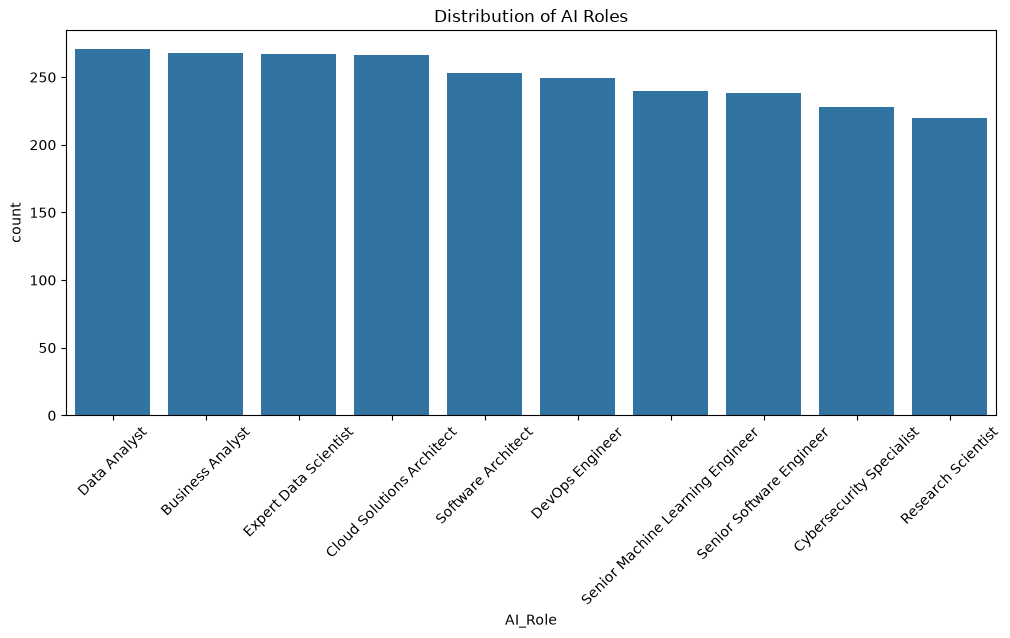

In [12]:
plt.figure(figsize=(12,5))

sns.countplot(data=df,
              x="AI_Role",
              order=df["AI_Role"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Distribution of AI Roles")

plt.show()

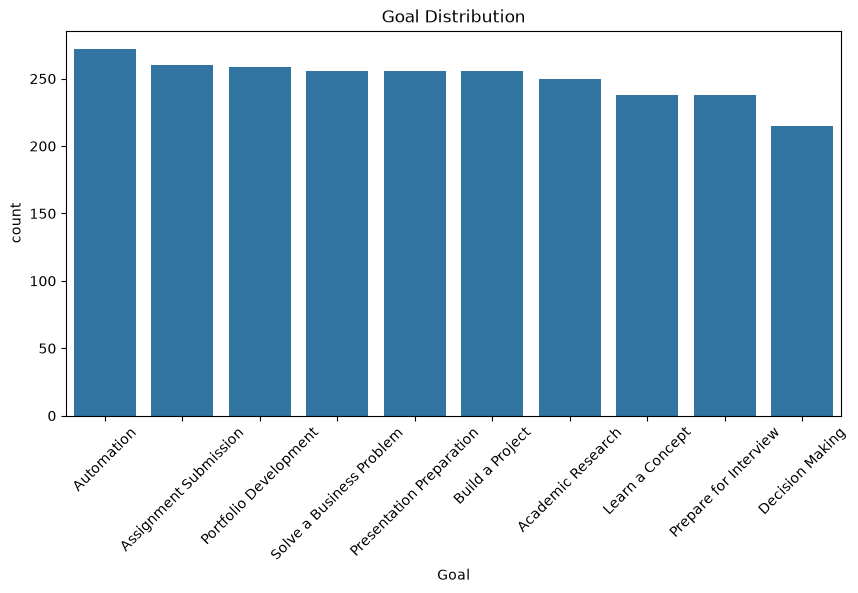

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="Goal",
              order=df["Goal"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Goal Distribution")

plt.show()

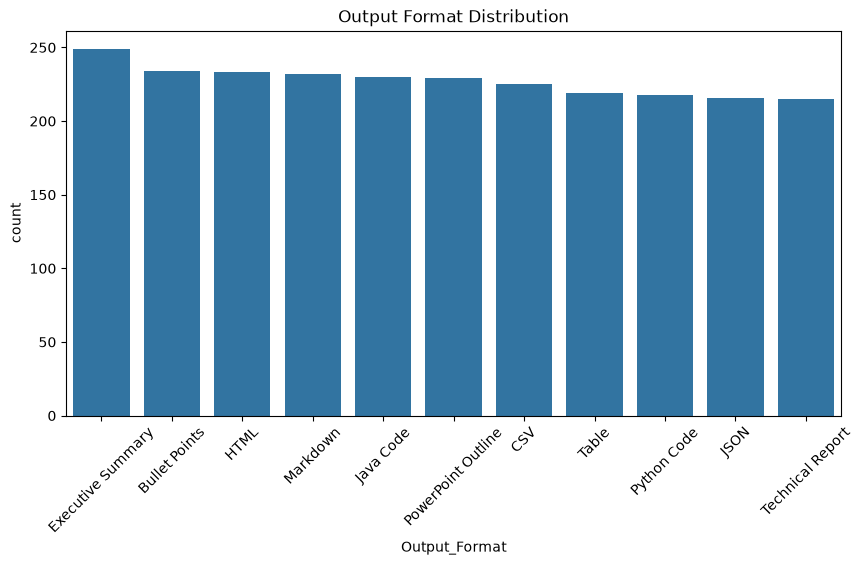

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,
              x="Output_Format",
              order=df["Output_Format"].value_counts().index)

plt.xticks(rotation=45)

plt.title("Output Format Distribution")

plt.show()

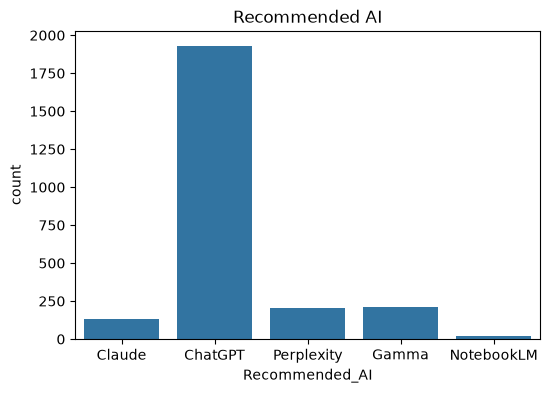

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Recommended_AI")

plt.title("Recommended AI")

plt.show()

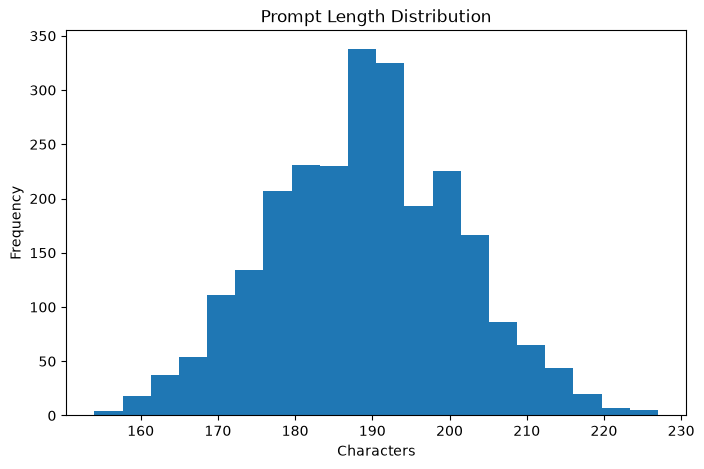

In [16]:
df["Prompt_Length"] = df["Generated_Prompt"].apply(len)

plt.figure(figsize=(8,5))

plt.hist(df["Prompt_Length"], bins=20)

plt.title("Prompt Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

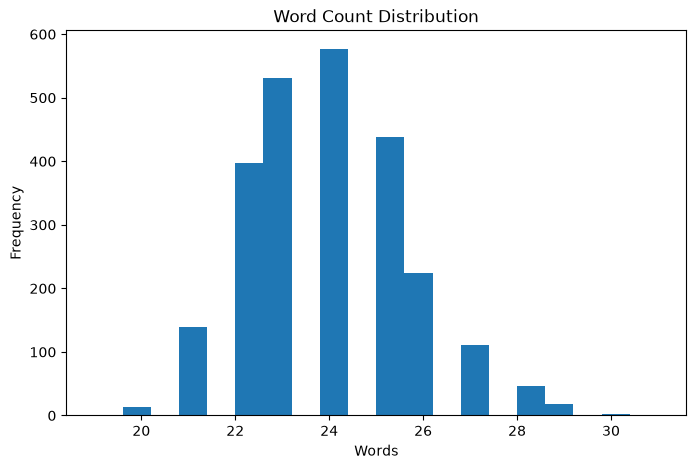

In [18]:
df["Word_Count"] = df["Generated_Prompt"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))

plt.hist(df["Word_Count"], bins=20)

plt.title("Word Count Distribution")

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

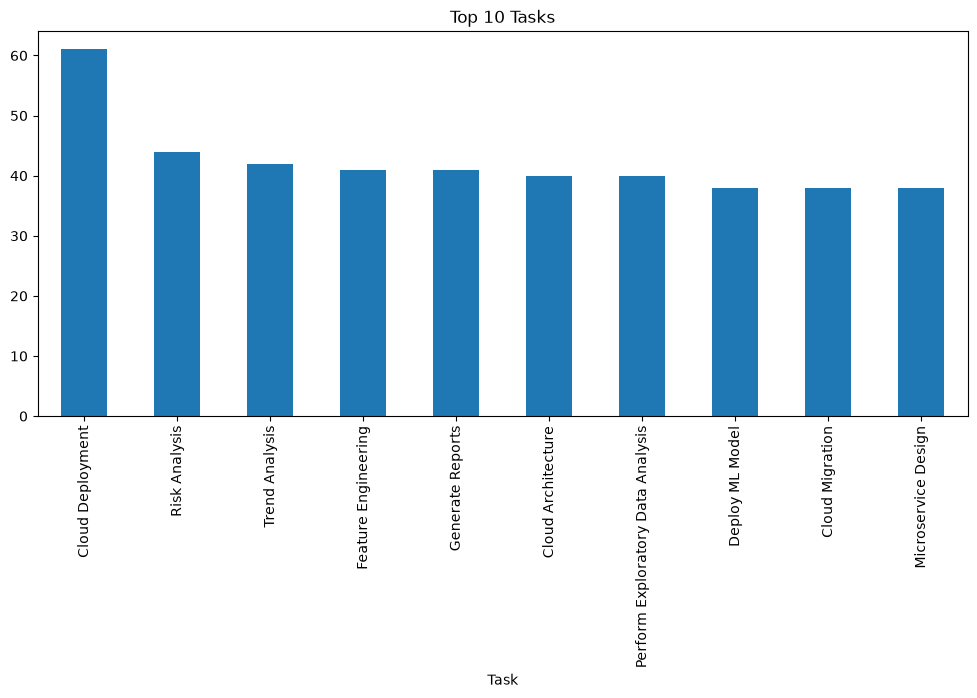

In [19]:
plt.figure(figsize=(12,5))

df["Task"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Tasks")

plt.show()

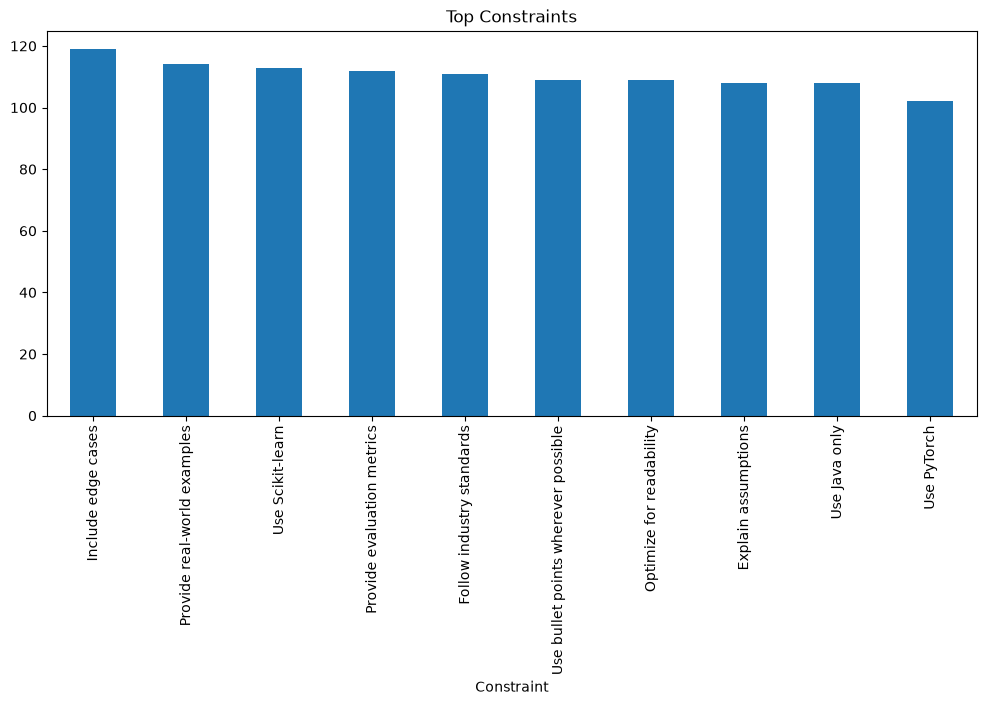

In [20]:
plt.figure(figsize=(12,5))

df["Constraint"].value_counts().head(10).plot(kind="bar")

plt.title("Top Constraints")

plt.show()

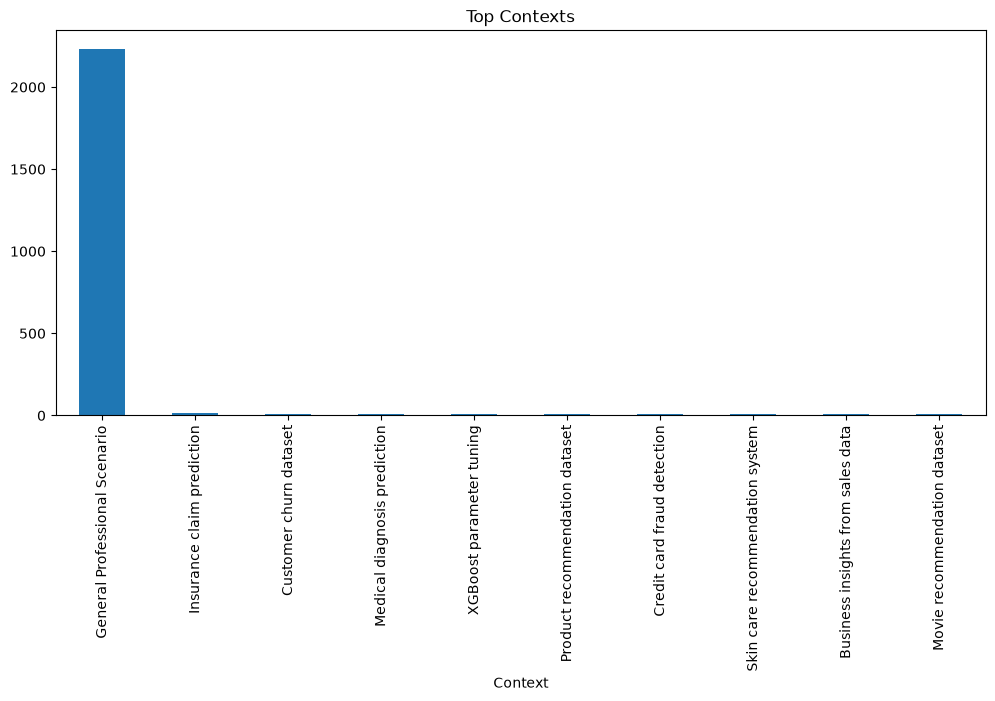

In [21]:
plt.figure(figsize=(12,5))

df["Context"].value_counts().head(10).plot(kind="bar")

plt.title("Top Contexts")

plt.show()

In [22]:
pd.crosstab(df["AI_Role"],
            df["Goal"])

Goal,Academic Research,Assignment Submission,Automation,Build a Project,Decision Making,Learn a Concept,Portfolio Development,Prepare for Interview,Presentation Preparation,Solve a Business Problem
AI_Role,,,,,,,,,,
Business Analyst,23,28,35,30,19,25,30,28,20,30
Cloud Solutions Architect,43,29,29,22,17,26,29,17,38,16
Cybersecurity Specialist,25,29,26,25,20,15,21,30,17,20
Data Analyst,19,28,33,29,31,16,29,25,31,30
DevOps Engineer,24,31,23,29,17,25,24,24,27,25
Expert Data Scientist,24,24,33,24,27,17,32,26,26,34
Research Scientist,19,22,31,13,19,26,20,19,23,28
Senior Machine Learning Engineer,26,23,23,24,20,27,29,18,26,24
Senior Software Engineer,22,29,17,29,24,24,22,25,18,28
